# Multi-Agent Target Tracking via a Time-Expanded Cellular Sheaf

This example uses a time-expanded sheaf to study how coordination constraints
determine the space of feasible agent trajectories.  Four scenarios are compared;
the nullspace dimension of the restricted sheaf Laplacian measures how many
free degrees of freedom remain after constraints are imposed.

**Vehicle model.** Each agent or target is a planar quadrotor.  The state is
$$
x = [y,\, z,\, \varphi,\, \dot y,\, \dot z,\, \dot\varphi]^\top \in \mathbb{R}^6
$$
where $y$ is the lateral position, $z$ is the altitude, and $\varphi$ is
the roll angle.  The control input is $u = [T_1, T_2]^\top \in \mathbb{R}^2$.

**Sheaf structure.** Each vertex $(\text{entity}, t)$ carries a stalk
$\mathbb{R}^{n_x + n_u} = \mathbb{R}^8$.  Three edge families encode:
1. *Dynamics*: $x_{t+1} = A_d x_t + B_d u_t$.
2. *Consensus*: inter-agent agreement on a chosen coordinate subspace.
3. *Tracking*: agent–target alignment in a chosen coordinate subspace.

By varying which coordinates are constrained and at which timesteps, we obtain
four qualitatively different solution spaces whose nullspace dimensions tell
the story of the engineering constraints.

The helper types (`TrackingEdge`, `TrackingProblem`, `BobbingTarget`,
`ScenarioResult`) and all solver utilities live in
`CellularSheaves.ControlSheaves.MultiAgentTracking` and can be reused by
other examples without copying code.

In [1]:
using CellularSheaves
using CellularSheaves.ControlSheaves.MultiAgentTracking
using CellularSheaves.TrajectorySheaves: continuous_to_discrete_zoh
using LinearAlgebra
using Plots

## Planar Quadrotor Dynamics

State: $x = [y, z, \varphi, \dot y, \dot z, \dot\varphi]$.
The linearisation is taken around the hover trim condition.

In [2]:
g     = 9.81
m_veh = 0.5
I_quad = 0.01
ell   = 0.25

Ac = [0.0  0.0   0.0   1.0  0.0  0.0;
      0.0  0.0   0.0   0.0  1.0  0.0;
      0.0  0.0   0.0   0.0  0.0  1.0;
      0.0  0.0  -g     0.0  0.0  0.0;
      0.0  0.0   0.0   0.0  0.0  0.0;
      0.0  0.0   0.0   0.0  0.0  0.0]

Bc = [0.0               0.0;
      0.0               0.0;
      0.0               0.0;
      0.0               0.0;
      1.0 / m_veh       1.0 / m_veh;
      ell / (2I_quad)  -ell / (2I_quad)]

h = 0.05
Ad, Bd = continuous_to_discrete_zoh(Ac, Bc, h)
nx = size(Ad, 1)
nu = size(Bd, 2)

2

State-index constants for the planar quadrotor.

In [3]:
IDX_Y   = 1   # lateral position y
IDX_Z   = 2   # altitude z
IDX_PHI = 3   # roll angle φ
IDX_YDT = 4   # ẏ
IDX_ZDT = 5   # ż
IDX_PHDT = 6  # φ̇

6

## Plot Recipe

A Plots.jl recipe renders a `ScenarioResult` as a two-panel $y(t)$ / $z(t)$
figure.  Agent trajectories use solid/dashed lines; target reference trajectories
are shown as dotted lines for comparison.

In [4]:
@recipe function f(sr::ScenarioResult)
    layout := (1, 2)
    size := (800, 380)
    plot_title := "$(sr.label): null dim = $(sr.null_dim),  ||dz|| = $(round(sr.residual; sigdigits=3))"
    agent_colors  = [:steelblue, :darkorange, :green, :crimson]
    agent_styles  = [:solid, :dash, :dashdot, :dot]
    target_colors = [:gray, :black, :darkgreen, :purple]
    for (i, traj) in enumerate(sr.agent_trajs)
        @series begin
            subplot   := 1
            title     := "y(t)"
            xlabel    := "t (s)"
            ylabel    := "y (m)"
            label     := "A$i"
            lw        := 2
            linecolor := agent_colors[i]
            linestyle := agent_styles[i]
            sr.times, traj[:, sr.y_col]
        end
        @series begin
            subplot   := 2
            title     := "z(t)"
            xlabel    := "t (s)"
            ylabel    := "z (m)"
            label     := "A$i"
            lw        := 2
            linecolor := agent_colors[i]
            linestyle := agent_styles[i]
            sr.times, traj[:, sr.z_col]
        end
    end
    for (j, traj_j) in enumerate(sr.target_trajs)
        @series begin
            subplot   := 1
            label     := "T$j"
            lw        := 1
            linecolor := target_colors[j]
            linestyle := :dot
            sr.times, getindex.(traj_j, IDX_Y)
        end
        @series begin
            subplot   := 2
            label     := "T$j"
            lw        := 1
            linecolor := target_colors[j]
            linestyle := :dot
            sr.times, getindex.(traj_j, IDX_Z)
        end
    end
end

## Common Setup

All four scenarios use two agents and two targets over a 40-step horizon (2 s).
The projection matrices are defined once and reused:

- $R_{yz}$: projects the $(n_x + n_u)$-stalk onto $(y, z)$ (Scenario 1).
- $R_y$: projects onto $y$ only (consensus in Scenarios 2–4).
- $R_z$: projects onto $z$ only (tracking in Scenarios 2–4).

In [5]:
n_agents  = 2
n_targets = 2
k         = 40
times     = h .* collect(0:k)

R_yz = state_projection_matrix([IDX_Y, IDX_Z], nx, nu)
R_y  = state_projection_matrix([IDX_Y],         nx, nu)
R_z  = state_projection_matrix([IDX_Z],         nx, nu)

1×8 Matrix{Float64}:
 0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0

Bobbing targets used in Scenarios 2–4.
Both complete two full vertical cycles over the 2-second horizon.

In [6]:
omega_2periods = 2π * 2 / (k * h)
bt1 = BobbingTarget(0.0, 1.0, 0.3, omega_2periods)
bt2 = BobbingTarget(0.0, 2.0, 0.3, omega_2periods)
traj_bt1 = trajectory(bt1, 0:k, h, nx, nu, IDX_Y, IDX_Z, IDX_ZDT)
traj_bt2 = trajectory(bt2, 0:k, h, nx, nu, IDX_Y, IDX_Z, IDX_ZDT)

41-element Vector{Vector{Float64}}:
 [0.0, 2.0, 0.0, 0.0, 1.8849555921538759, 0.0, 0.0, 0.0]
 [0.0, 2.0927050983124844, 0.0, 0.0, 1.7926992988449335, 0.0, 0.0, 0.0]
 [0.0, 2.176335575687742, 0.0, 0.0, 1.524961107694578, 0.0, 0.0, 0.0]
 [0.0, 2.2427050983124843, 0.0, 0.0, 1.107949098294274, 0.0, 0.0, 0.0]
 [0.0, 2.285316954888546, 0.0, 0.0, 0.58248331161764, 0.0, 0.0, 0.0]
 [0.0, 2.3, 0.0, 0.0, 1.1542024162330739e-16, 0.0, 0.0, 0.0]
 [0.0, 2.285316954888546, 0.0, 0.0, -0.5824833116176402, 0.0, 0.0, 0.0]
 [0.0, 2.2427050983124843, 0.0, 0.0, -1.107949098294274, 0.0, 0.0, 0.0]
 [0.0, 2.176335575687742, 0.0, 0.0, -1.5249611076945777, 0.0, 0.0, 0.0]
 [0.0, 2.0927050983124844, 0.0, 0.0, -1.7926992988449335, 0.0, 0.0, 0.0]
 ⋮
 [0.0, 1.8236644243122582, 0.0, 0.0, -1.5249611076945784, 0.0, 0.0, 0.0]
 [0.0, 1.757294901687516, 0.0, 0.0, -1.1079490982942746, 0.0, 0.0, 0.0]
 [0.0, 1.7146830451114539, 0.0, 0.0, -0.5824833116176374, 0.0, 0.0, 0.0]
 [0.0, 1.7, 0.0, 0.0, -8.079416913631517e-16, 0.0, 0.0

Named edge configurations reused across scenarios.

In [7]:
edges_12 = [(1, 2)]
te_yz = [TrackingEdge(1, 1, R_yz, R_yz), TrackingEdge(2, 2, R_yz, R_yz)]
te_z  = [TrackingEdge(1, 1, R_z,  R_z),  TrackingEdge(2, 2, R_z,  R_z)]

2-element Vector{CellularSheaves.ControlSheaves.MultiAgentTracking.TrackingEdge}:
 CellularSheaves.ControlSheaves.MultiAgentTracking.TrackingEdge(1, 1, [0.0 1.0 … 0.0 0.0], [0.0 1.0 … 0.0 0.0])
 CellularSheaves.ControlSheaves.MultiAgentTracking.TrackingEdge(2, 2, [0.0 1.0 … 0.0 0.0], [0.0 1.0 … 0.0 0.0])

## Scenario 1: Full (y,z) Coordination at Every Timestep

Both consensus and tracking edges use the $(y, z)$ projection, active at
**every** timestep.

The two agents travel to distinct goals while each tracking its own target in
full $(y, z)$.  But the consensus edge demands that agents agree in $(y, z)$
at every step.  Since the two targets travel *different* $(y, z)$
trajectories, the constraints "A1 tracks T1", "A2 tracks T2", and
"A1 agrees with A2 in $(y,z)$" are **mutually incompatible** unless the
targets coincide.  The sheaf Laplacian has no kernel (null dim = 0) and
`harmonic_extension` returns the least-squares compromise with a nonzero
residual $\|dz\| > 0$.

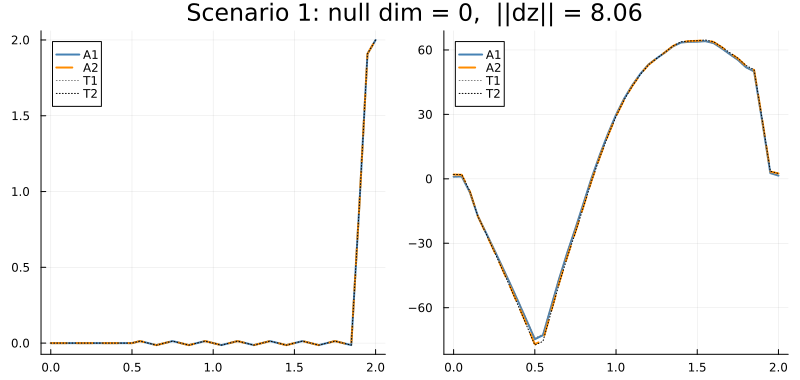

In [8]:
x0_a1_s1 = [0.0, 1.0, 0.0, 0.0, 0.0, 0.0]
xk_a1_s1 = [2.0, 1.5, 0.0, 0.0, 0.0, 0.0]
x0_a2_s1 = [0.0, 2.0, 0.0, 0.0, 0.0, 0.0]
xk_a2_s1 = [2.0, 2.5, 0.0, 0.0, 0.0, 0.0]

traj_t1_s1 = generate_reference_trajectory(x0_a1_s1, xk_a1_s1, k, Ad, Bd, nx, nu)
traj_t2_s1 = generate_reference_trajectory(x0_a2_s1, xk_a2_s1, k, Ad, Bd, nx, nu)

prob1 = TrackingProblem(
    n_agents, n_targets, k, Matrix(Ad), Matrix(Bd),
    edges_12, te_yz, R_yz,
    collect(0:k), collect(0:k),
    true, 1.0, 5.0,
)

bnd1 = Dict{Int,Vector{Float64}}()
bnd1[agent_vertex(prob1, 1, 0)] = vcat(x0_a1_s1, zeros(nu))
bnd1[agent_vertex(prob1, 2, 0)] = vcat(x0_a2_s1, zeros(nu))
bnd1[agent_vertex(prob1, 1, k)] = vcat(xk_a1_s1, zeros(nu))
bnd1[agent_vertex(prob1, 2, k)] = vcat(xk_a2_s1, zeros(nu))
for t in 0:k
    bnd1[target_vertex(prob1, 1, t)] = traj_t1_s1[t + 1]
    bnd1[target_vertex(prob1, 2, t)] = traj_t2_s1[t + 1]
end

result1 = run_scenario("Scenario 1", prob1, bnd1, times;
    target_trajs = [traj_t1_s1, traj_t2_s1], y_col = IDX_Y, z_col = IDX_Z)

plot(result1)

## Scenario 2: y-Consensus and z-Tracking, All Timesteps, Aligned Initial Conditions

Targets bob vertically.  Consensus edges constrain agents to agree only on
**lateral position** $y$; tracking edges constrain each agent to match its
assigned target in **altitude** $z$.  Both edge families are active at every
timestep.

Because the two targets share $y = 0$ and the consensus only constrains $y$,
the system is consistent: agents can agree in $y$ while independently tracking
different altitudes.  A non-trivial nullspace (null dim > 0) arises because
$z$ (and all other state components) remain unconstrained by the consensus
edges.  The `TrackingEdge` API makes it natural to assign different projection
matrices to each agent–target pair.

Since all target vertices are pinned as boundary data, target dynamics edges
are omitted (`include_target_dynamics = false`).

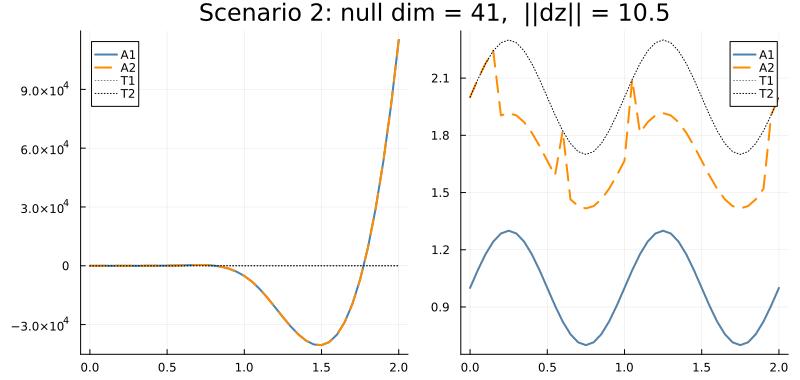

In [9]:
prob2 = TrackingProblem(
    n_agents, n_targets, k, Matrix(Ad), Matrix(Bd),
    edges_12, te_z, R_y,
    collect(0:k), collect(0:k),
    false, 1.0, 5.0,
)

x0_a1_s2 = [0.0, traj_bt1[1][IDX_Z], 0.0, 0.0, traj_bt1[1][IDX_ZDT], 0.0]
x0_a2_s2 = [0.0, traj_bt2[1][IDX_Z], 0.0, 0.0, traj_bt2[1][IDX_ZDT], 0.0]

bnd2 = Dict{Int,Vector{Float64}}()
bnd2[agent_vertex(prob2, 1, 0)] = vcat(x0_a1_s2, zeros(nu))
bnd2[agent_vertex(prob2, 2, 0)] = vcat(x0_a2_s2, zeros(nu))
for t in 0:k
    bnd2[target_vertex(prob2, 1, t)] = traj_bt1[t + 1]
    bnd2[target_vertex(prob2, 2, t)] = traj_bt2[t + 1]
end

result2 = run_scenario("Scenario 2", prob2, bnd2, times;
    target_trajs = [traj_bt1, traj_bt2], y_col = IDX_Y, z_col = IDX_Z)

plot(result2)

## Scenario 3: y-Consensus and z-Tracking at the Last Timestep Only

The same projection matrices as Scenario 2, but coordination edges are
active **only at** $t = k$.  Agents evolve freely (dynamics only) for
$t = 0, \ldots, k-1$ and must converge to the terminal constraint.

Both targets share $y = 0$ (laterally aligned), but agents start misaligned
with each other and with the targets in both $y$ and $z$.
Removing $k$ timesteps of coordination edges dramatically enlarges the
feasible space (null dim >> Scenario 2).

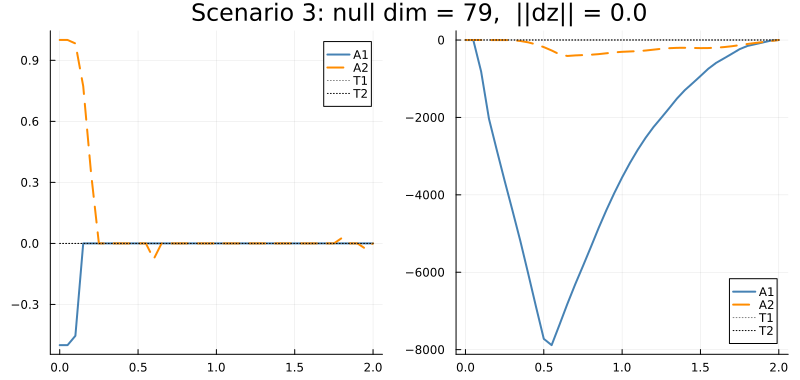

In [10]:
prob3 = TrackingProblem(
    n_agents, n_targets, k, Matrix(Ad), Matrix(Bd),
    edges_12, te_z, R_y,
    [k], [k],
    false, 1.0, 5.0,
)

x0_a1_s3 = [-0.5, 0.5, 0.0, 0.0, 0.0, 0.0]
x0_a2_s3 = [ 1.0, 1.5, 0.0, 0.0, 0.0, 0.0]

bnd3 = Dict{Int,Vector{Float64}}()
bnd3[agent_vertex(prob3, 1, 0)] = vcat(x0_a1_s3, zeros(nu))
bnd3[agent_vertex(prob3, 2, 0)] = vcat(x0_a2_s3, zeros(nu))
for t in 0:k
    bnd3[target_vertex(prob3, 1, t)] = traj_bt1[t + 1]
    bnd3[target_vertex(prob3, 2, t)] = traj_bt2[t + 1]
end

result3 = run_scenario("Scenario 3", prob3, bnd3, times;
    target_trajs = [traj_bt1, traj_bt2], y_col = IDX_Y, z_col = IDX_Z)

plot(result3)

## Scenario 4: Last-Timestep Constraints, Targets Not Aligned in y or z

Identical sheaf topology to Scenario 3, but Target 2 is now at $y = 1.5$ m
instead of $y = 0$.  The targets are **not** initially aligned with each other
in either $y$ or $z$.

Because the sheaf topology (which edges exist at which timesteps) is unchanged,
the restricted Laplacian's nullspace has the **same dimension** as Scenario 3.
The two harmonic extensions produce different trajectories, but they live in
equally large affine solution spaces, confirming that nullspace dimension is a
structural property of the coordination architecture, not of the boundary data.

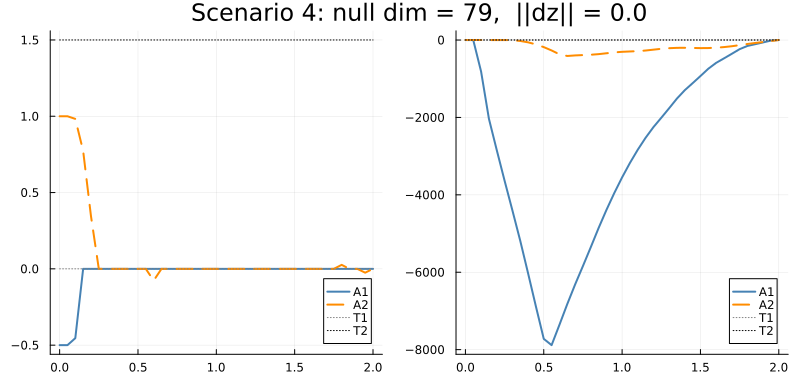

In [11]:
bt2_s4 = BobbingTarget(1.5, 2.0, 0.3, omega_2periods)
traj_bt2_s4 = trajectory(bt2_s4, 0:k, h, nx, nu, IDX_Y, IDX_Z, IDX_ZDT)

prob4 = TrackingProblem(
    n_agents, n_targets, k, Matrix(Ad), Matrix(Bd),
    edges_12, te_z, R_y,
    [k], [k],
    false, 1.0, 5.0,
)

x0_a1_s4 = [-0.5, 0.5, 0.0, 0.0, 0.0, 0.0]
x0_a2_s4 = [ 1.0, 1.5, 0.0, 0.0, 0.0, 0.0]

bnd4 = Dict{Int,Vector{Float64}}()
bnd4[agent_vertex(prob4, 1, 0)] = vcat(x0_a1_s4, zeros(nu))
bnd4[agent_vertex(prob4, 2, 0)] = vcat(x0_a2_s4, zeros(nu))
for t in 0:k
    bnd4[target_vertex(prob4, 1, t)] = traj_bt1[t + 1]
    bnd4[target_vertex(prob4, 2, t)] = traj_bt2_s4[t + 1]
end

result4 = run_scenario("Scenario 4", prob4, bnd4, times;
    target_trajs = [traj_bt1, traj_bt2_s4], y_col = IDX_Y, z_col = IDX_Z)

plot(result4)

## Comparison: How Constraints Shape the Solution Space

The four scenarios are summarised below.  The nullspace dimension and
Laplacian residual $\|dz\|$ are displayed via the `ScenarioResult` show method.

| Scenario | Consensus | Tracking | Active timesteps | Initial alignment |
|----------|-----------|----------|-----------------|-------------------|
| 1 | $(y,z)$ | $(y,z)$ | all $0:k$ | distinct endpoints |
| 2 | $y$     | $z$     | all $0:k$ | aligned with targets |
| 3 | $y$     | $z$     | terminal $k$ | unaligned; targets share $y$ |
| 4 | $y$     | $z$     | terminal $k$ | unaligned; targets offset in $y$ |

**Constraint density governs nullspace size.**
Scenario 1 is infeasible: the $(y,z)$ consensus edge forces agents to share
the same trajectory in the $yz$-plane, but tracking edges demand they follow
different targets.  The result is null dim = 0 with a nonzero least-squares
residual — the energy minimiser finds a compromise, not a feasible trajectory.
Scenario 2 (only $y$ consensus + $z$ tracking, all timesteps) is consistent
and admits a family of solutions (null dim > 0) because fewer coordinates per
edge are constrained.
Restricting to the terminal timestep only (Scenarios 3–4) removes $k$ sets of
constraints and dramatically enlarges the solution space.

**Nullspace dimension is a topological invariant.**
Scenarios 3 and 4 share the same sheaf topology (identical edge structure) and
therefore the same nullspace dimension, even though their target trajectories
differ.  The harmonic extensions produce different specific trajectories, but
they live in equally large affine spaces.  The nullspace dimension is a property
of the *coordination architecture*, not the *boundary data*.

**Feasibility is separate from trajectory shape.**
In Scenario 2, agents start consistent with all-time constraints, so the harmonic
solution closely tracks the bobbing targets.  In Scenarios 3–4, agents start
misaligned; the minimum-energy harmonic path converges to the terminal constraint
while the large nullspace deforms it freely in the unconstrained directions.

ScenarioResult:
  label    : Scenario 1
  null dim : 0
  ||dz||   : 8.063
  agents   : 2
  targets  : 2
ScenarioResult:
  label    : Scenario 2
  null dim : 41
  ||dz||   : 10.5
  agents   : 2
  targets  : 2
ScenarioResult:
  label    : Scenario 3
  null dim : 79
  ||dz||   : 0.0
  agents   : 2
  targets  : 2
ScenarioResult:
  label    : Scenario 4
  null dim : 79
  ||dz||   : 0.0
  agents   : 2
  targets  : 2


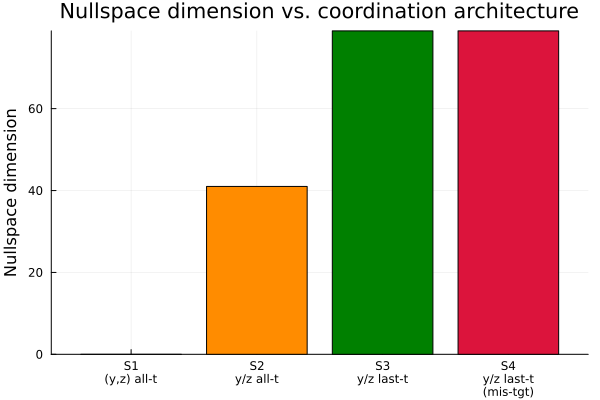

In [12]:
for r in (result1, result2, result3, result4)
    show(stdout, MIME("text/plain"), r); println()
end

bar(["S1\n(y,z) all-t", "S2\ny/z all-t", "S3\ny/z last-t", "S4\ny/z last-t\n(mis-tgt)"],
    [result1.null_dim, result2.null_dim, result3.null_dim, result4.null_dim];
    ylabel = "Nullspace dimension",
    title  = "Nullspace dimension vs. coordination architecture",
    legend = false,
    color  = [:steelblue, :darkorange, :green, :crimson])